In [1]:
# import libraries
import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

In [4]:
#initialize and variables
load_dotenv(override=True)

GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")
MODEL = "gemini-3.5-flash"
gemini = OpenAI(api_key=GEMINI_API_KEY, base_url=GEMINI_BASE_URL)
DB = "prices.db"

In [3]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [5]:
# Let's start by making a useful function

ticket_prices = {"london": "$799", "paris": "$899", "tokyo": "$1400", "berlin": "$499"}

def get_ticket_price(destination_city):
    print(f"Tool called for city {destination_city}")
    price = ticket_prices.get(destination_city.lower(), "Unknown ticket price")
    return f"The price of a ticket to {destination_city} is {price}"

In [6]:
get_ticket_price("London")

Tool called for city London


'The price of a ticket to London is $799'

In [7]:
# There's a particular dictionary structure that's required to describe the above function:

price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}

In [8]:
tools = [{"type": "function", "function": price_function}]

In [9]:
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

### Getting Gemini to use our Tool

In [10]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = gemini.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    if response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        response = handle_tool_call(message)
        messages.append(message)
        messages.append(response)
        response = gemini.chat.completions.create(model=MODEL, messages=messages)
    
    return response.choices[0].message.content

In [11]:
# We have to write that function handle_tool_call:

def handle_tool_call(message):
    tool_call = message.tool_calls[0]
    if tool_call.function.name == "get_ticket_price":
        arguments = json.loads(tool_call.function.arguments)
        city = arguments.get('destination_city')
        price_details = get_ticket_price(city)
        response = {
            "role": "tool",
            "content": price_details,
            "tool_call_id": tool_call.id
        }
    return response

In [12]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Tool called for city London
Tool called for city London


Traceback (most recent call last):
  File "/Users/sadikurrahmankhan/llm_projects/llm_engineering/.venv/lib/python3.12/site-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sadikurrahmankhan/llm_projects/llm_engineering/.venv/lib/python3.12/site-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sadikurrahmankhan/llm_projects/llm_engineering/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sadikurrahmankhan/llm_projects/llm_engineering/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 1621, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/s

### Let's make a couple of improvements
_In the code above, we handle only the first call. That's why, when we want to go to London, the assistant is able to help us. But if we ask for London and Paris, then it cannot handled then. Now we will handle it so that it can handle multiple calls. Let's improve our handle_tool_call function._

In [16]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = gemini.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    if response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = gemini.chat.completions.create(model=MODEL, messages=messages)
    
    return response.choices[0].message.content

In [17]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [18]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


Tool called for city London
Tool called for city Paris
Tool called for city London
Tool called for city Paris
Tool called for city London


Traceback (most recent call last):
  File "/Users/sadikurrahmankhan/llm_projects/llm_engineering/.venv/lib/python3.12/site-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sadikurrahmankhan/llm_projects/llm_engineering/.venv/lib/python3.12/site-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sadikurrahmankhan/llm_projects/llm_engineering/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sadikurrahmankhan/llm_projects/llm_engineering/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 1621, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/s

In the above, when we call the multiple call, then it shows error!

### Another update to handle multiple tool calls

In [22]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = gemini.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":    # while instead of if
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = gemini.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [ ]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


Tool called for city London
Tool called for city Paris


### Now creating database to handle this

In [24]:
DB = "prices.db"

with sqlite3.connect(DB) as conn:
    cursor = conn.cursor()
    cursor.execute('CREATE TABLE IF NOT EXISTS prices (city TEXT PRIMARY KEY, price REAL)')
    conn.commit()

In [25]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [26]:
get_ticket_price("London")

DATABASE TOOL CALLED: Getting price for London


'No price data available for this city'

_Now the database is empty. So, it's time to create a function to set ticket prices_

In [27]:
def set_ticket_price(city, price):
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('INSERT INTO prices (city, price) VALUES (?, ?) ON CONFLICT(city) DO UPDATE SET price = ?', (city.lower(), price, price))
        conn.commit()

In [28]:
ticket_prices = {"london":799, "paris": 899, "tokyo": 1420, "sydney": 2999}
for city, price in ticket_prices.items():
    set_ticket_price(city, price)

In [29]:
get_ticket_price("Tokyo")

DATABASE TOOL CALLED: Getting price for Tokyo


'Ticket price to Tokyo is $1420.0'

### Let's go multi-modal!!

In [46]:
# Some imports for handling images

import io
import base64
import requests
import urllib.parse
from io import BytesIO
from PIL import Image
from google import genai
from google.genai import types

In [ ]:

# Function for creating image in pop-art style
def artist(city):
    prompt = f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style"
    
    encoded_prompt = urllib.parse.quote(prompt)
    url = f"https://image.pollinations.ai/prompt/{encoded_prompt}?width=1024&height=1024&nologo=true"
    
    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            return Image.open(io.BytesIO(response.content))
        else:
            print("Error generating image, status code:", response.status_code)
            return None
    except Exception as e:
        print("Network Error:", e)
        return None

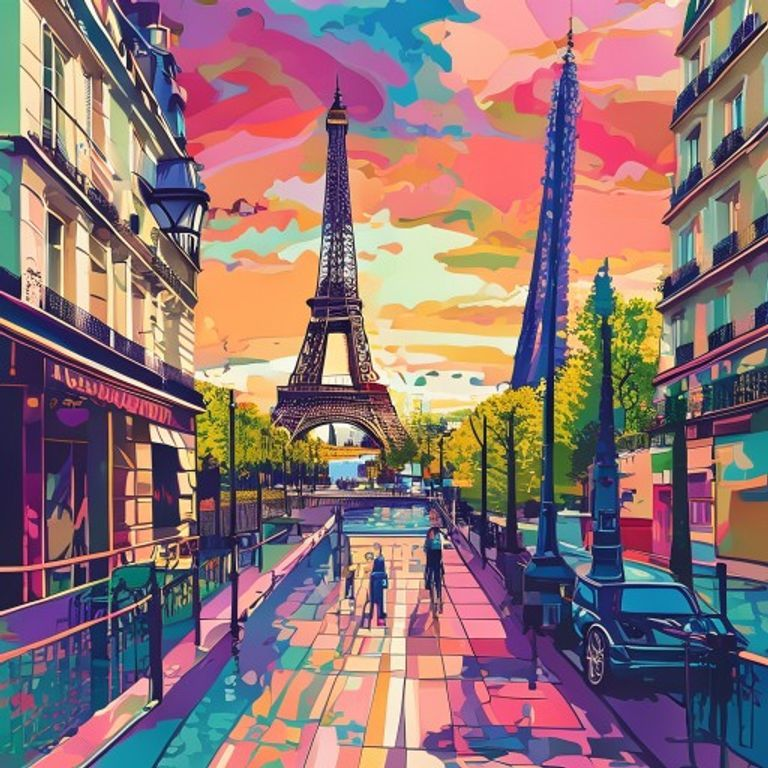

In [78]:
image = artist("Paris")
display(image)

In [74]:
from gtts import gTTS


def talker(message):
    try:
        tts = gTTS(text=message, lang="en", slow=False)
        audio_filepath = "response.wav"
        tts.save(audio_filepath)
        return audio_filepath
    except Exception as e:
        print("Audio generation error:", e)
        return None

In [75]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = gemini.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = gemini.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image

In [76]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

In [79]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inline = True)

* Running on local URL:  http://127.0.0.1:7874
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for Paris
